# Audio Classification Using CNN

## Objective

This notebook implements an audio classification system using a Convolutional Neural Network (CNN) on the Speech Commands Dataset.

Two experiments are performed:

- Part A: CNN without SpecAugment
- Part B: CNN with SpecAugment

The performances of both models are compared using accuracy, precision, recall, F1-score and confusion matrices.

---

## Dataset

Speech Commands Dataset v0.02

https://arxiv.org/abs/1804.03209

https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz

In [1]:
import os
import random
import librosa
import librosa.display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Audio

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Load and Explore the Dataset

The Speech Commands Dataset contains thousands of one-second recordings belonging to multiple spoken-word classes.

This section scans the dataset folders and prepares a dataframe containing:

- file path
- class label

In [2]:
DATASET_PATH = r"D:\onboarding-audio\task4\speech_commands_v0.02"

classes = []

file_paths = []

labels = []

for folder in sorted(os.listdir(DATASET_PATH)):

    folder_path = os.path.join(DATASET_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    if folder.startswith("_"):
        continue

    classes.append(folder)

    for file in os.listdir(folder_path):

        if file.endswith(".wav"):

            file_paths.append(os.path.join(folder_path, file))

            labels.append(folder)

df = pd.DataFrame({
    "path": file_paths,
    "label": labels
})

print("Number of classes :", len(classes))
print("Total audio files :", len(df))

df.head()

Number of classes : 35
Total audio files : 105829


,path,label
0,D:\onboarding-audio\task4\speech_commands_v0.0...,backward
1,D:\onboarding-audio\task4\speech_commands_v0.0...,backward
2,D:\onboarding-audio\task4\speech_commands_v0.0...,backward
3,D:\onboarding-audio\task4\speech_commands_v0.0...,backward
4,D:\onboarding-audio\task4\speech_commands_v0.0...,backward


In [3]:
import os
import librosa
import pandas as pd

DATASET_PATH = r"D:\onboarding-audio\task4\speech_commands_v0.02"

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
    and not d.startswith("_")
])

sample_counts = []
durations = []
sample_rates = []

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    wav_files = [
        f for f in os.listdir(folder)
        if f.endswith(".wav")
    ]

    sample_counts.append(len(wav_files))

    # Read one file to determine sample rate
    audio_path = os.path.join(folder, wav_files[0])
    y, sr = librosa.load(audio_path, sr=None)

    sample_rates.append(sr)

    total_duration = len(wav_files) * 1.0      # each clip ≈1 second
    durations.append(total_duration)

summary = pd.DataFrame({
    "Class": classes,
    "Samples": sample_counts,
    "Duration (sec)": durations,
    "Sample Rate": sample_rates
})

summary

,Class,Samples,Duration (sec),Sample Rate
0,backward,1664,1664.0,16000
1,bed,2014,2014.0,16000
2,bird,2064,2064.0,16000
3,cat,2031,2031.0,16000
4,dog,2128,2128.0,16000
5,down,3917,3917.0,16000
6,eight,3787,3787.0,16000
7,five,4052,4052.0,16000
8,follow,1579,1579.0,16000
9,forward,1557,1557.0,16000


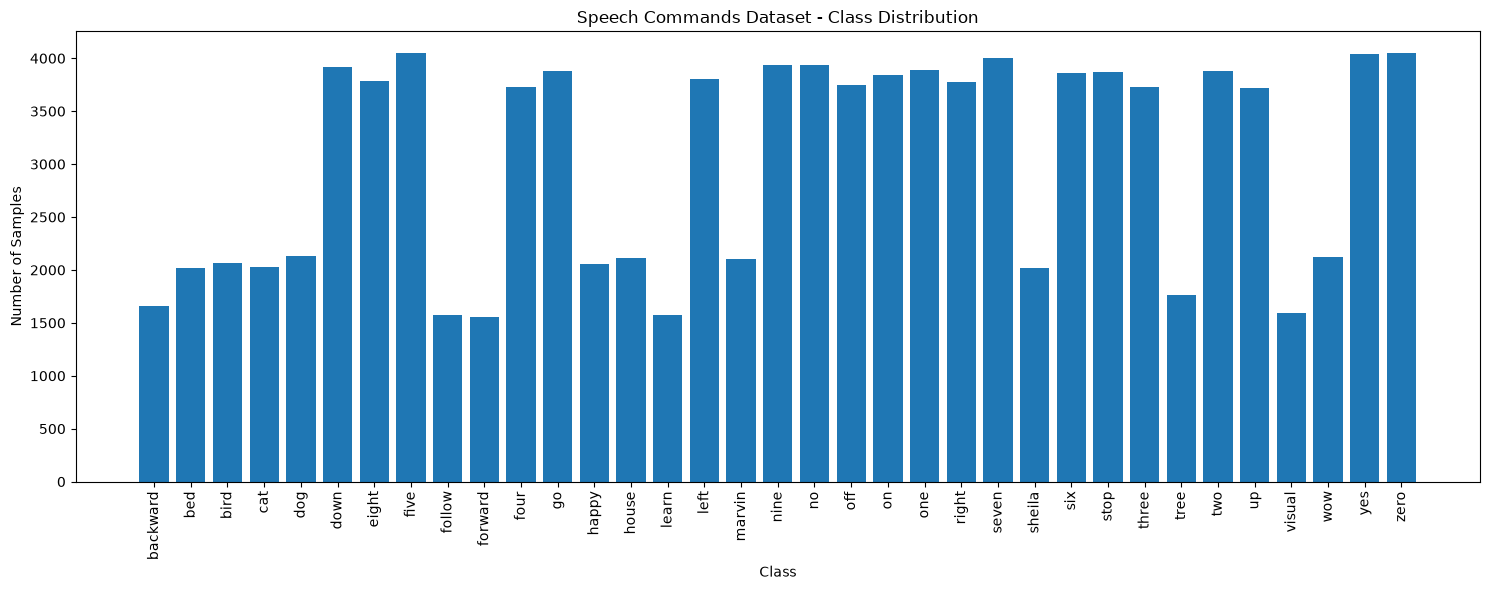

In [4]:
plt.figure(figsize=(15,6))
plt.bar(summary["Class"], summary["Samples"])
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Speech Commands Dataset - Class Distribution")
plt.tight_layout()
plt.show()

In [5]:
print("Number of classes :", len(classes))
print("Total audio files :", summary["Samples"].sum())
print("Sample rate       :", summary["Sample Rate"].iloc[0], "Hz")
print("Total duration    :", summary["Duration (sec)"].sum()/3600, "hours")

Number of classes : 35
Total audio files : 105829
Sample rate       : 16000 Hz
Total duration    : 29.396944444444443 hours


# Step 1: Dataset Study

In this section, we explore the Speech Commands dataset.

The following information is extracted:

- Number of classes
- Number of samples per class
- Total dataset duration
- Sample rate
- Class distribution

We also visualize one audio sample from each class using:

- Waveform
- Mel Spectrogram

In [6]:
import os
import pandas as pd

summary = []

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    files = [f for f in os.listdir(folder) if f.endswith(".wav")]

    summary.append({
        "Class": cls,
        "Samples": len(files),
        "Approx Duration (sec)": len(files),   # each clip ≈1 second
        "Sample Rate": 16000
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

print("Total Classes :", len(summary_df))
print("Total Samples :", summary_df["Samples"].sum())

,Class,Samples,Approx Duration (sec),Sample Rate
0,backward,1664,1664,16000
1,bed,2014,2014,16000
2,bird,2064,2064,16000
3,cat,2031,2031,16000
4,dog,2128,2128,16000
5,down,3917,3917,16000
6,eight,3787,3787,16000
7,five,4052,4052,16000
8,follow,1579,1579,16000
9,forward,1557,1557,16000


Total Classes : 35
Total Samples : 105829


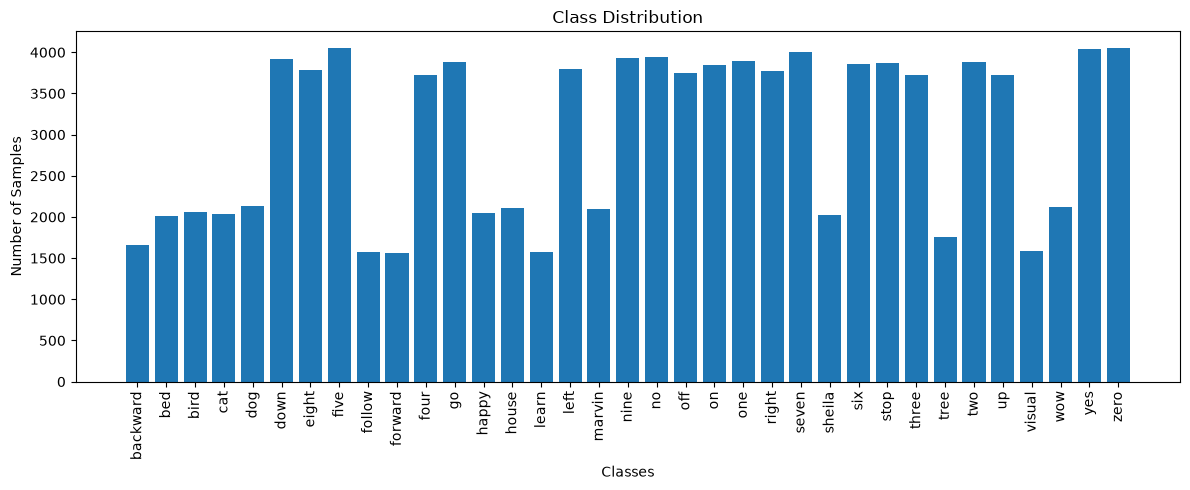

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    summary_df["Class"],
    summary_df["Samples"]
)

plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

In [8]:
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.pyplot as plt

In [9]:
sample_files = []

for cls in classes:

    folder = os.path.join(
        DATASET_PATH,
        cls
    )

    wav_files = [
        f for f in os.listdir(folder)
        if f.endswith(".wav")
    ]

    sample_files.append(
        (
            cls,
            os.path.join(folder, wav_files[0])
        )
    )


sample_files[:5]

[('backward',
  'D:\\onboarding-audio\\task4\\speech_commands_v0.02\\backward\\0165e0e8_nohash_0.wav'),
 ('bed',
  'D:\\onboarding-audio\\task4\\speech_commands_v0.02\\bed\\00176480_nohash_0.wav'),
 ('bird',
  'D:\\onboarding-audio\\task4\\speech_commands_v0.02\\bird\\00970ce1_nohash_0.wav'),
 ('cat',
  'D:\\onboarding-audio\\task4\\speech_commands_v0.02\\cat\\004ae714_nohash_0.wav'),
 ('dog',
  'D:\\onboarding-audio\\task4\\speech_commands_v0.02\\dog\\00b01445_nohash_0.wav')]


Class: backward
File: D:\onboarding-audio\task4\speech_commands_v0.02\backward\0165e0e8_nohash_0.wav


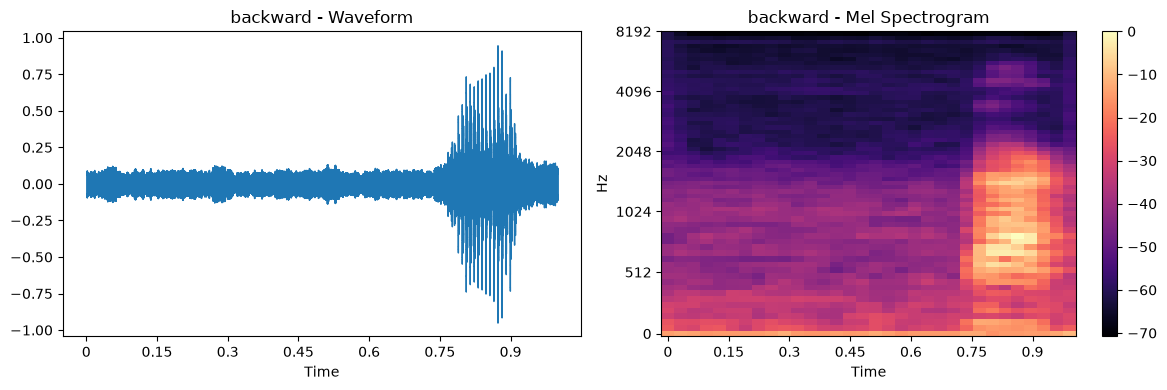


Class: bed
File: D:\onboarding-audio\task4\speech_commands_v0.02\bed\00176480_nohash_0.wav


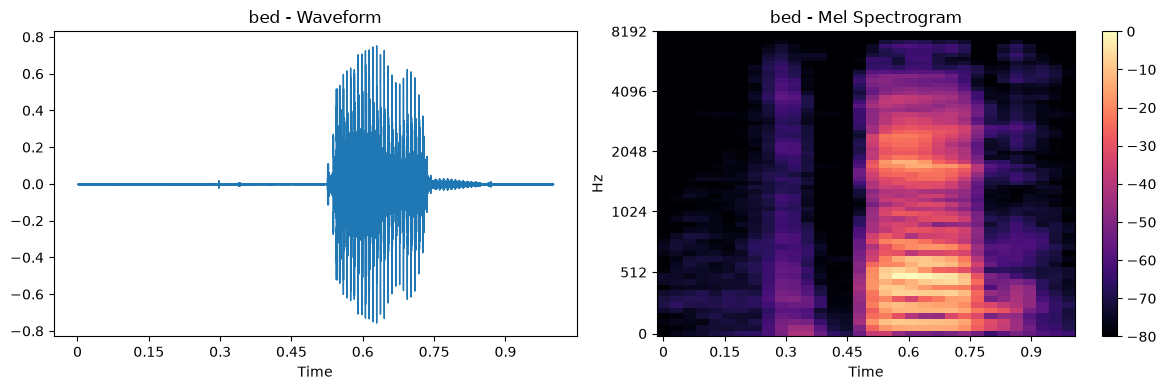


Class: bird
File: D:\onboarding-audio\task4\speech_commands_v0.02\bird\00970ce1_nohash_0.wav


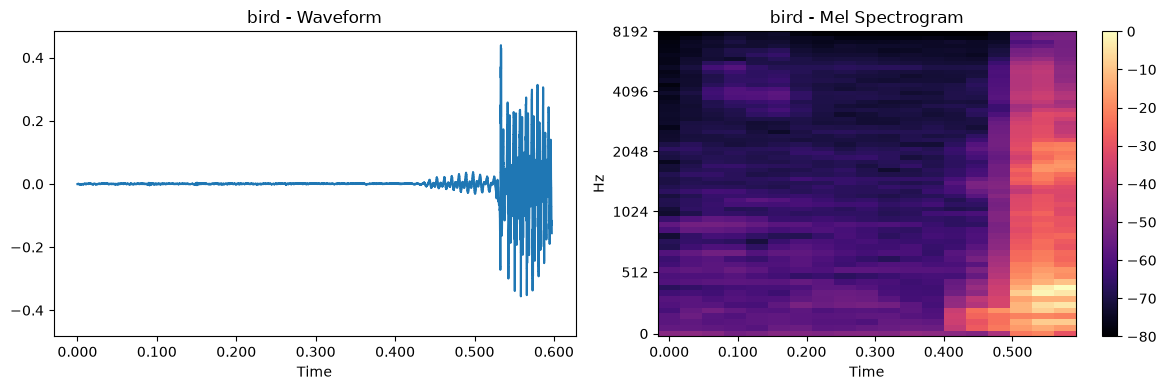


Class: cat
File: D:\onboarding-audio\task4\speech_commands_v0.02\cat\004ae714_nohash_0.wav


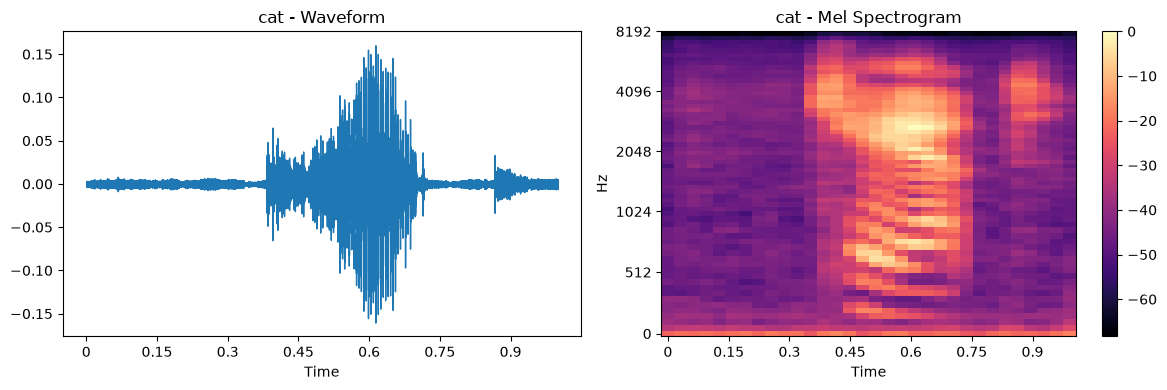


Class: dog
File: D:\onboarding-audio\task4\speech_commands_v0.02\dog\00b01445_nohash_0.wav


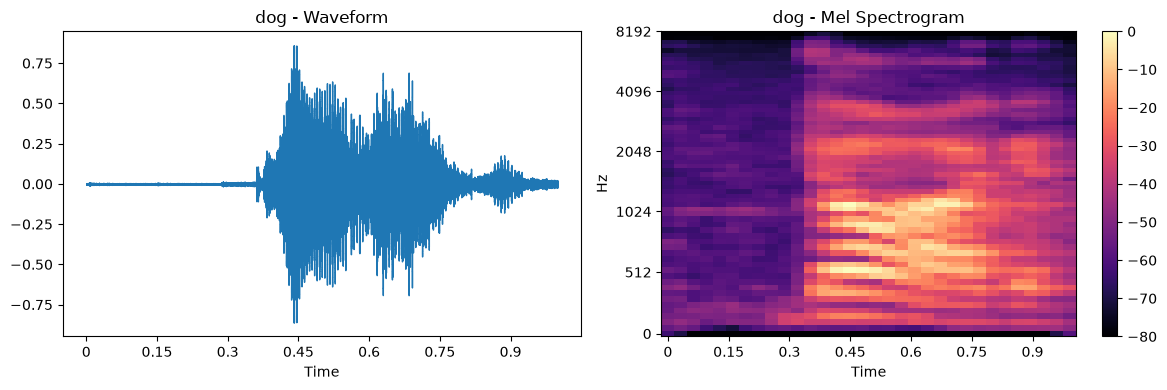


Class: down
File: D:\onboarding-audio\task4\speech_commands_v0.02\down\00176480_nohash_0.wav


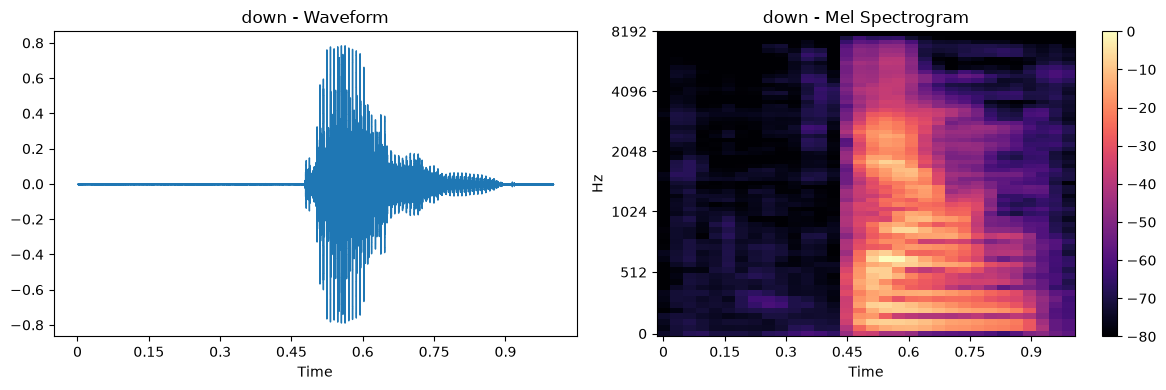


Class: eight
File: D:\onboarding-audio\task4\speech_commands_v0.02\eight\004ae714_nohash_0.wav


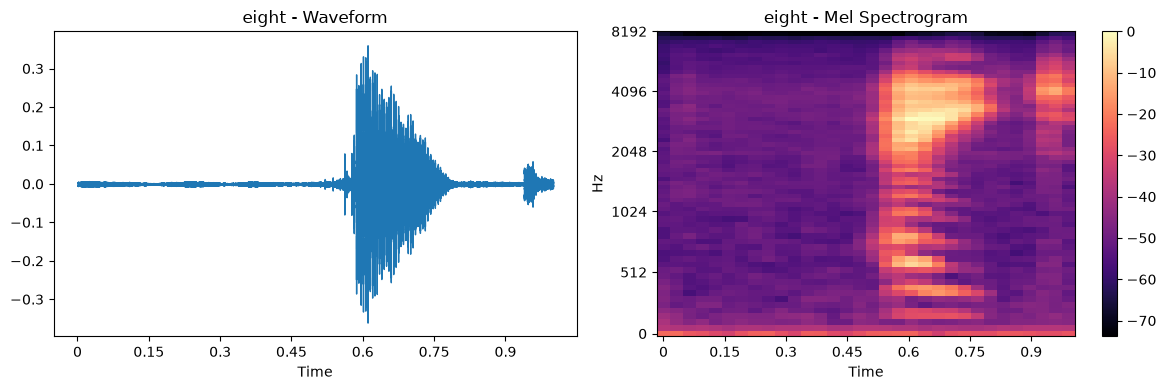


Class: five
File: D:\onboarding-audio\task4\speech_commands_v0.02\five\004ae714_nohash_0.wav


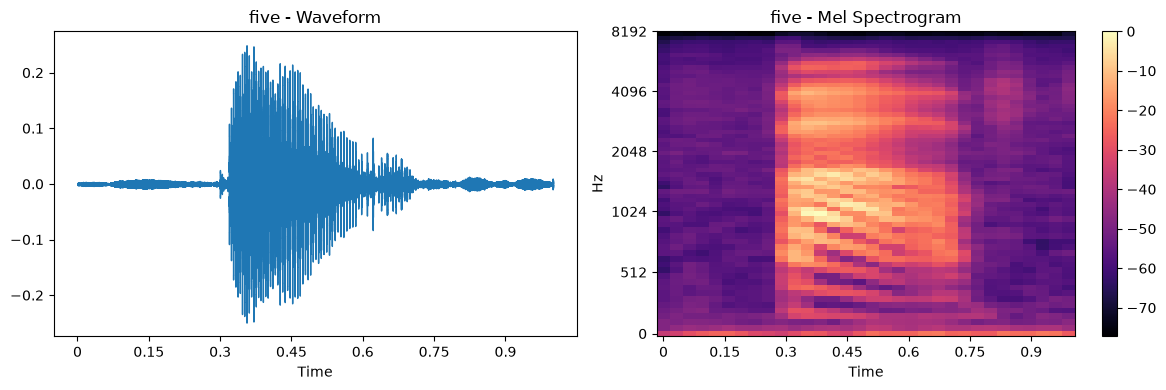


Class: follow
File: D:\onboarding-audio\task4\speech_commands_v0.02\follow\00970ce1_nohash_0.wav


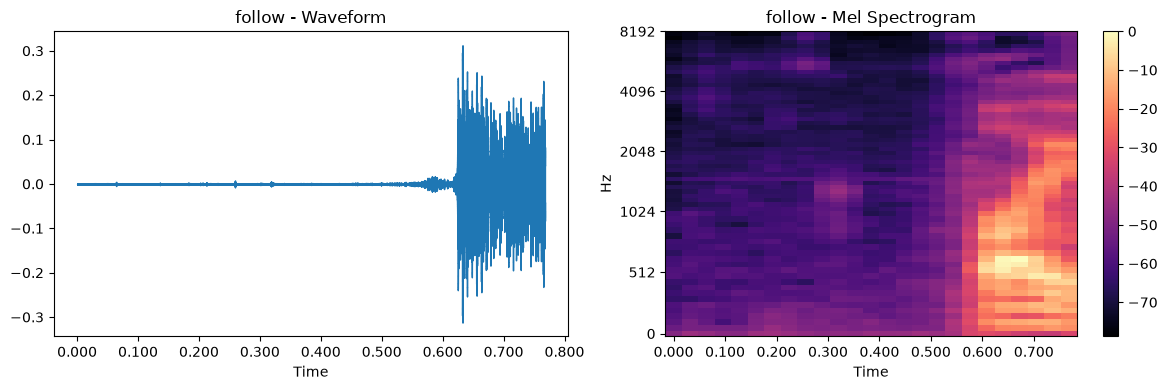


Class: forward
File: D:\onboarding-audio\task4\speech_commands_v0.02\forward\012187a4_nohash_0.wav


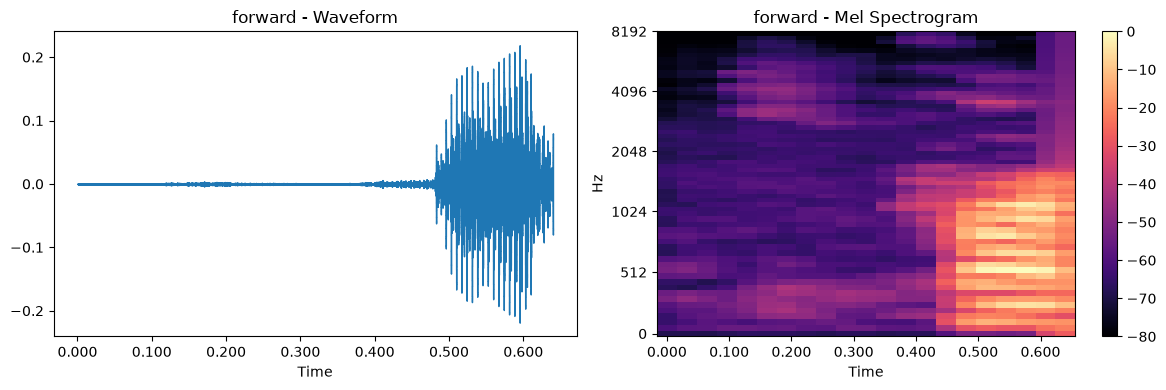


Class: four
File: D:\onboarding-audio\task4\speech_commands_v0.02\four\004ae714_nohash_0.wav


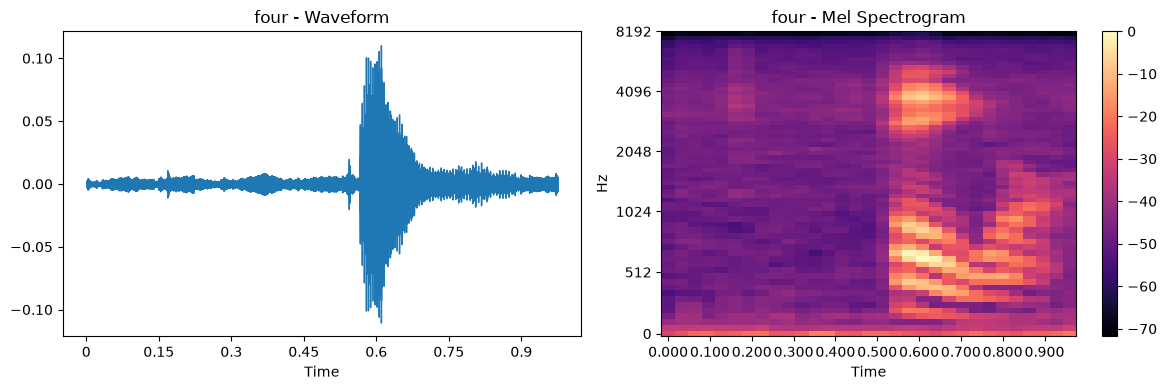


Class: go
File: D:\onboarding-audio\task4\speech_commands_v0.02\go\004ae714_nohash_0.wav


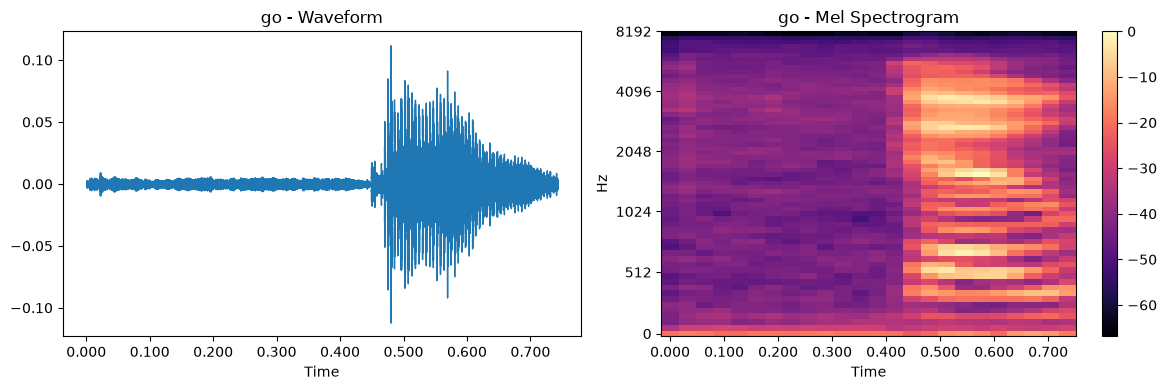


Class: happy
File: D:\onboarding-audio\task4\speech_commands_v0.02\happy\00970ce1_nohash_0.wav


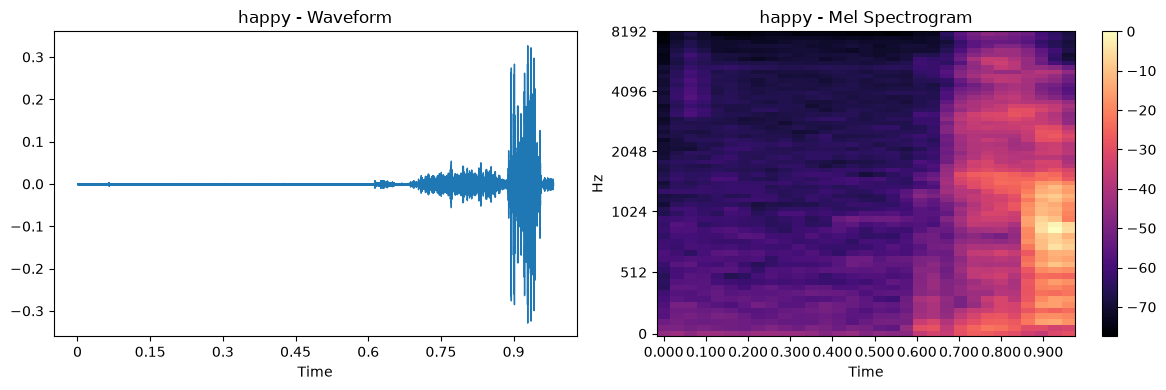


Class: house
File: D:\onboarding-audio\task4\speech_commands_v0.02\house\00970ce1_nohash_0.wav


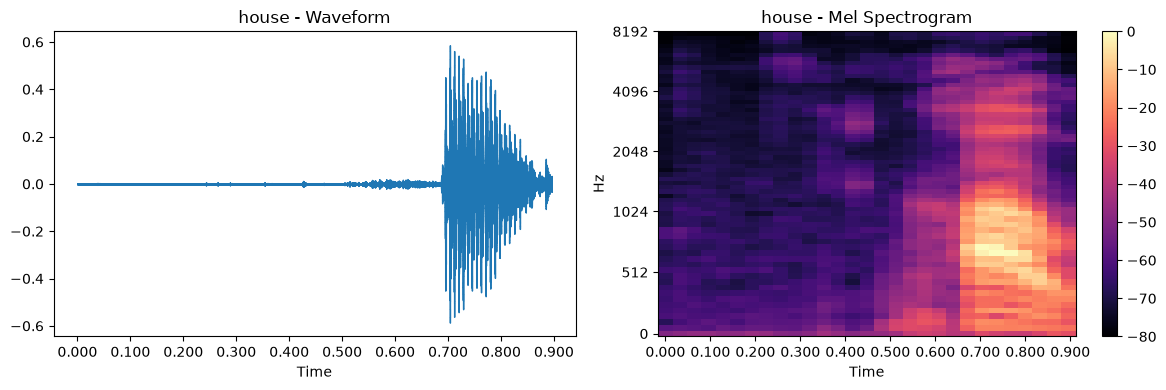


Class: learn
File: D:\onboarding-audio\task4\speech_commands_v0.02\learn\00761705_nohash_0.wav


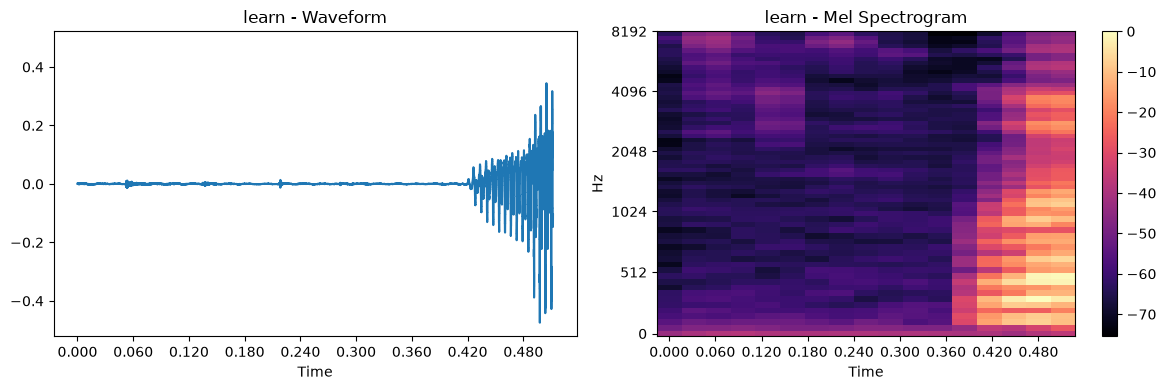


Class: left
File: D:\onboarding-audio\task4\speech_commands_v0.02\left\00176480_nohash_0.wav


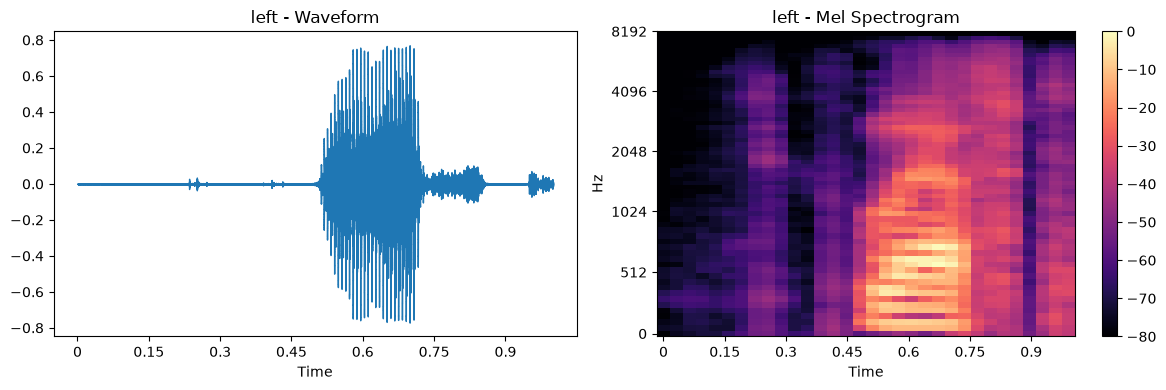


Class: marvin
File: D:\onboarding-audio\task4\speech_commands_v0.02\marvin\00176480_nohash_0.wav


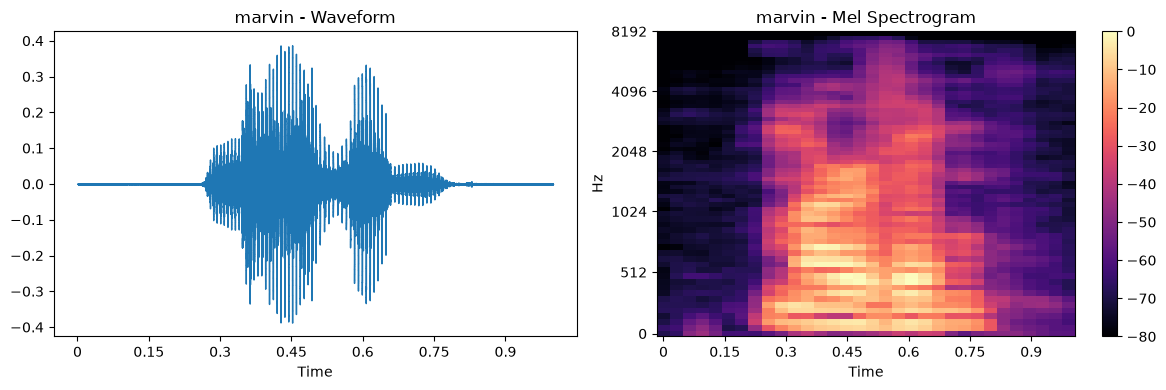


Class: nine
File: D:\onboarding-audio\task4\speech_commands_v0.02\nine\00b01445_nohash_0.wav


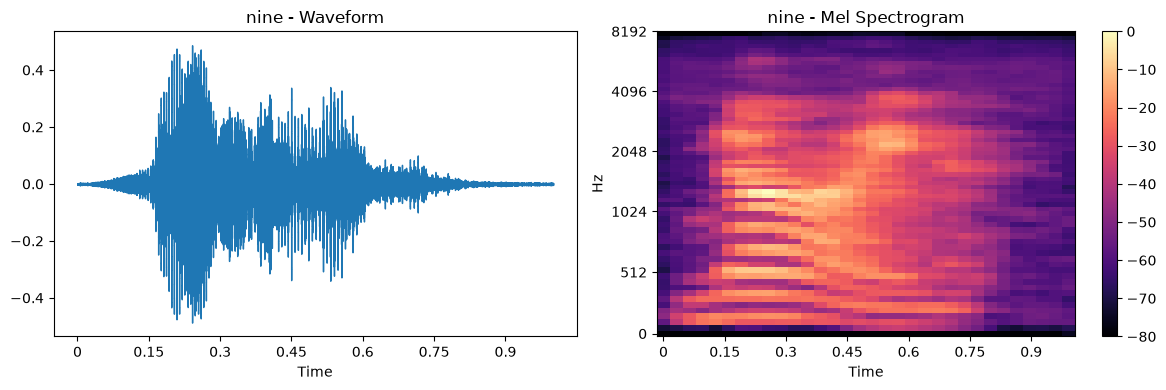


Class: no
File: D:\onboarding-audio\task4\speech_commands_v0.02\no\012c8314_nohash_0.wav


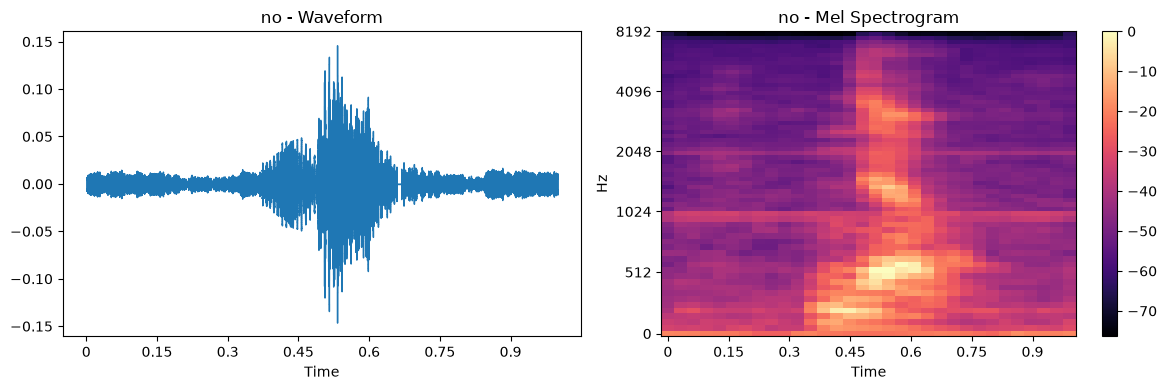


Class: off
File: D:\onboarding-audio\task4\speech_commands_v0.02\off\00176480_nohash_0.wav


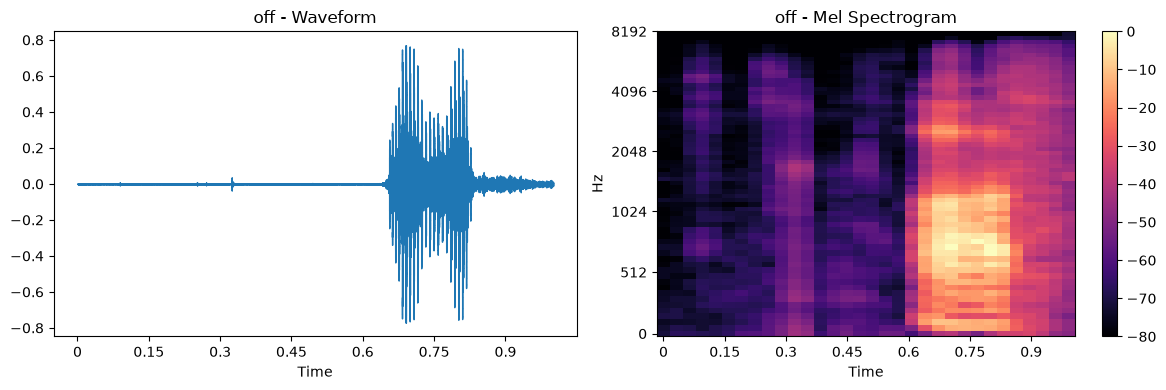


Class: on
File: D:\onboarding-audio\task4\speech_commands_v0.02\on\004ae714_nohash_0.wav


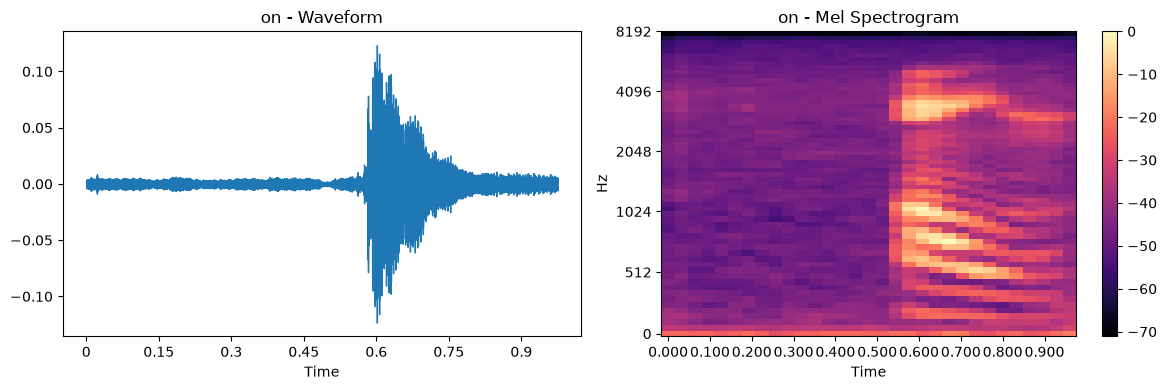


Class: one
File: D:\onboarding-audio\task4\speech_commands_v0.02\one\00176480_nohash_0.wav


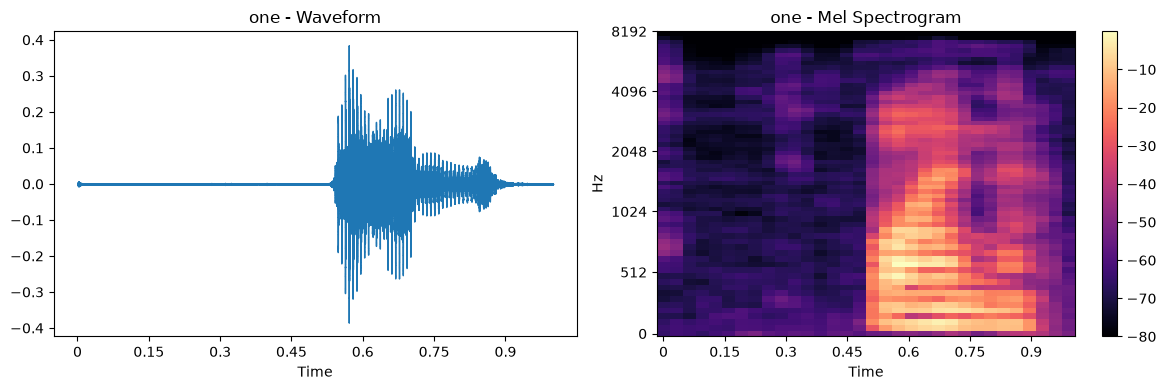


Class: right
File: D:\onboarding-audio\task4\speech_commands_v0.02\right\00b01445_nohash_0.wav


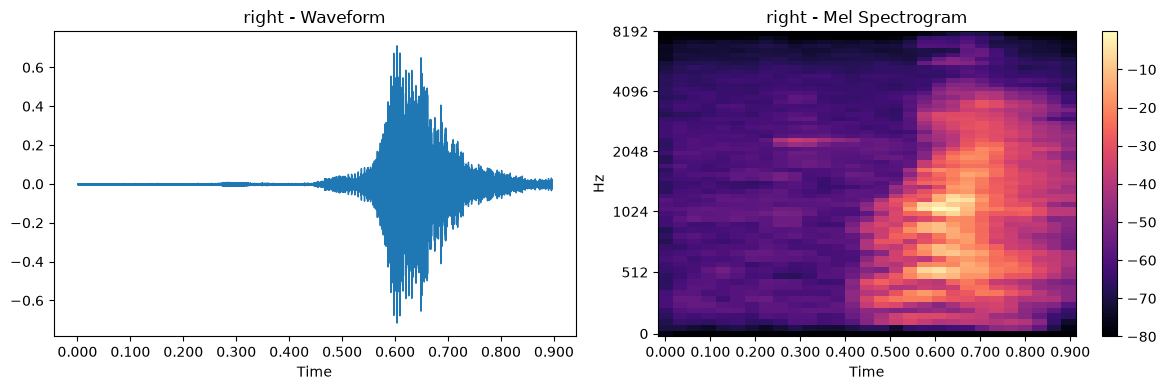


Class: seven
File: D:\onboarding-audio\task4\speech_commands_v0.02\seven\004ae714_nohash_0.wav


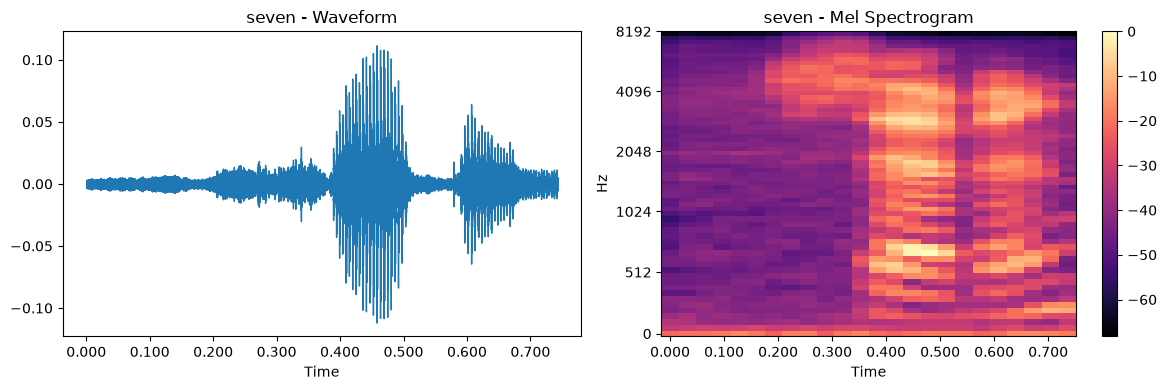


Class: sheila
File: D:\onboarding-audio\task4\speech_commands_v0.02\sheila\004ae714_nohash_0.wav


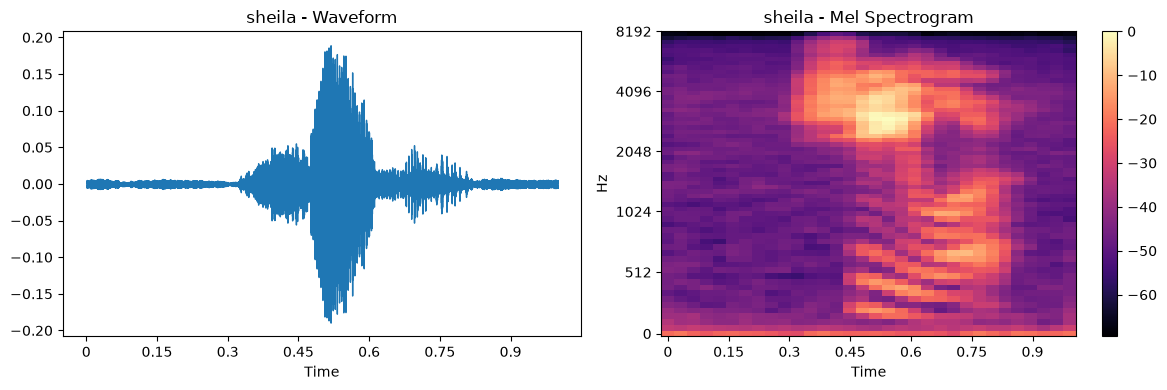


Class: six
File: D:\onboarding-audio\task4\speech_commands_v0.02\six\004ae714_nohash_0.wav


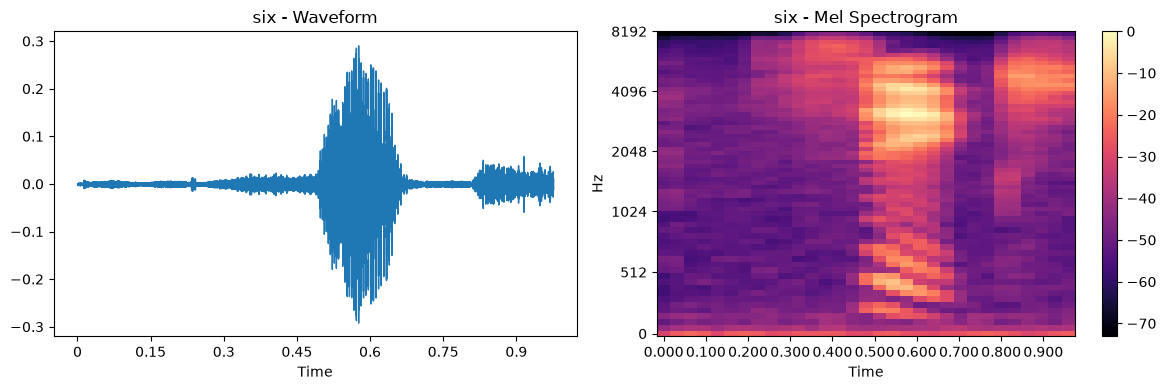


Class: stop
File: D:\onboarding-audio\task4\speech_commands_v0.02\stop\004ae714_nohash_0.wav


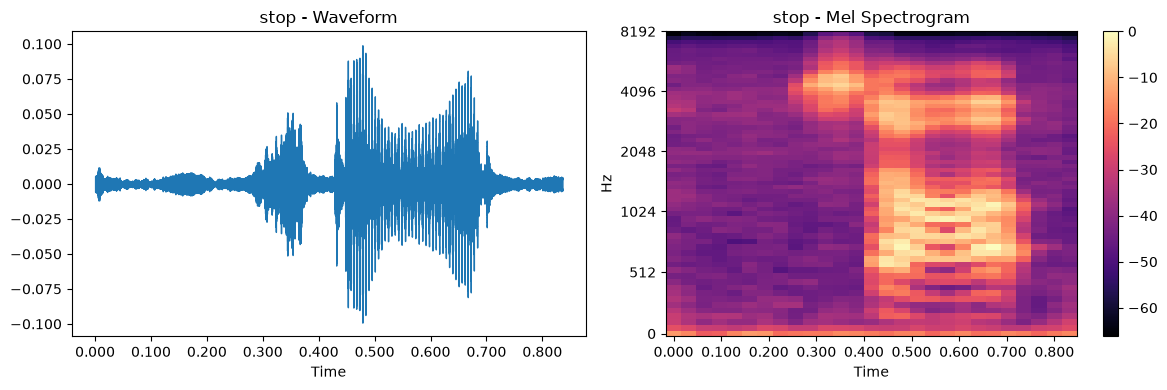


Class: three
File: D:\onboarding-audio\task4\speech_commands_v0.02\three\00970ce1_nohash_0.wav


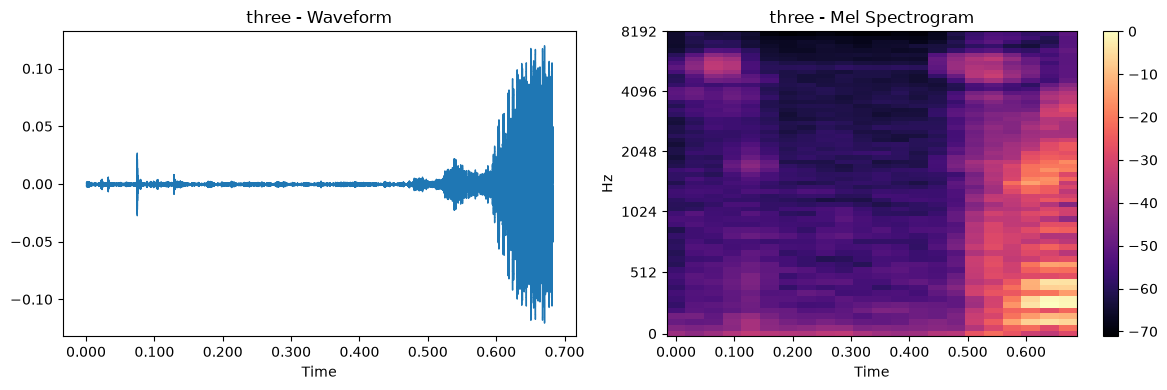


Class: tree
File: D:\onboarding-audio\task4\speech_commands_v0.02\tree\00b01445_nohash_0.wav


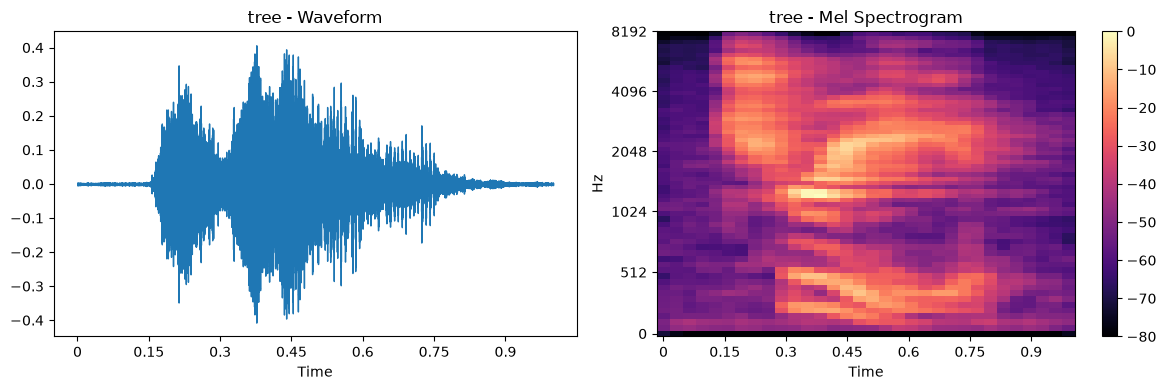


Class: two
File: D:\onboarding-audio\task4\speech_commands_v0.02\two\00b01445_nohash_0.wav


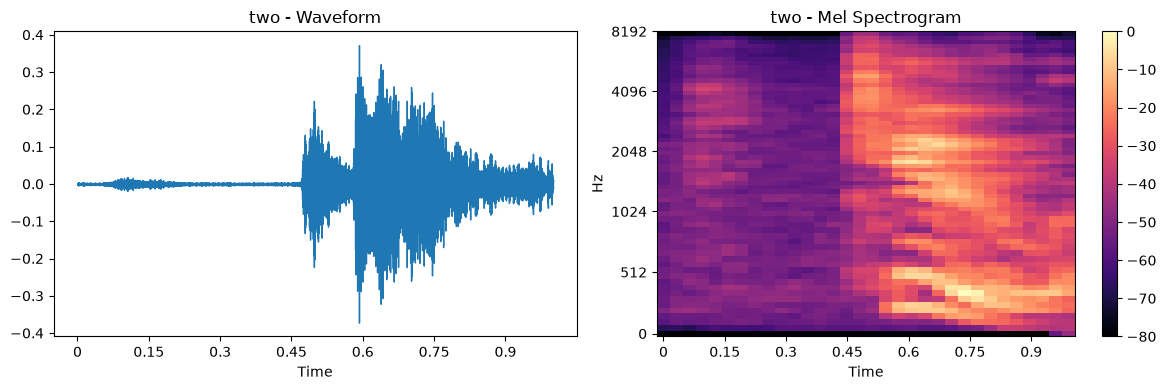


Class: up
File: D:\onboarding-audio\task4\speech_commands_v0.02\up\004ae714_nohash_0.wav


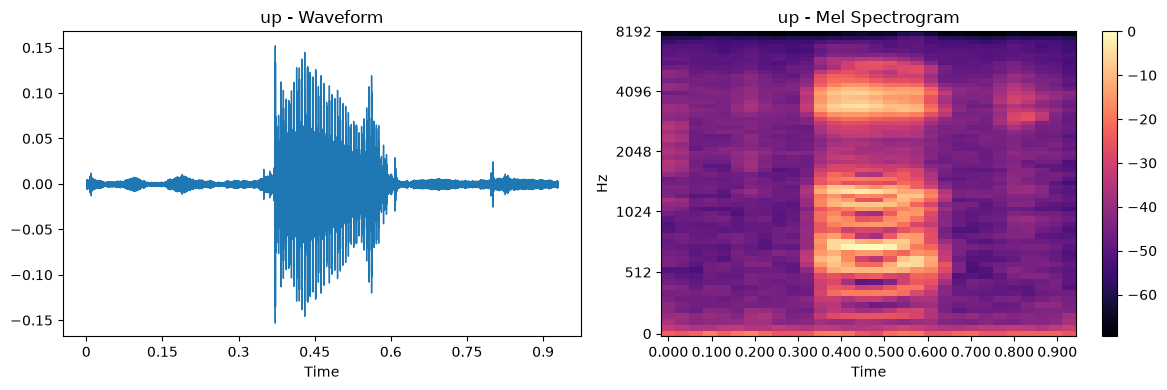


Class: visual
File: D:\onboarding-audio\task4\speech_commands_v0.02\visual\00970ce1_nohash_0.wav


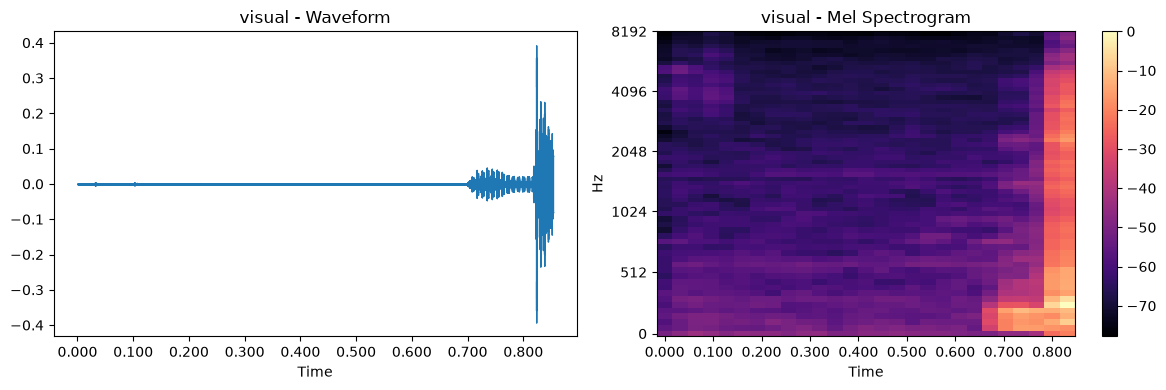


Class: wow
File: D:\onboarding-audio\task4\speech_commands_v0.02\wow\004ae714_nohash_0.wav


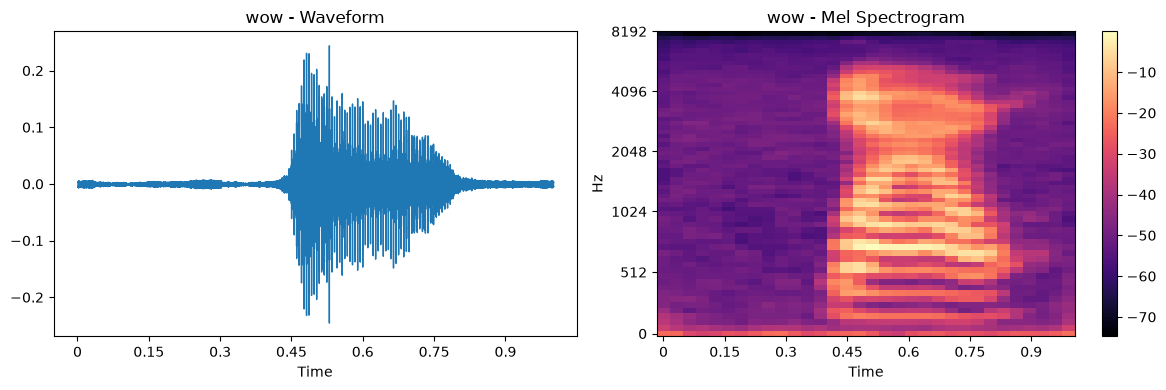


Class: yes
File: D:\onboarding-audio\task4\speech_commands_v0.02\yes\004ae714_nohash_0.wav


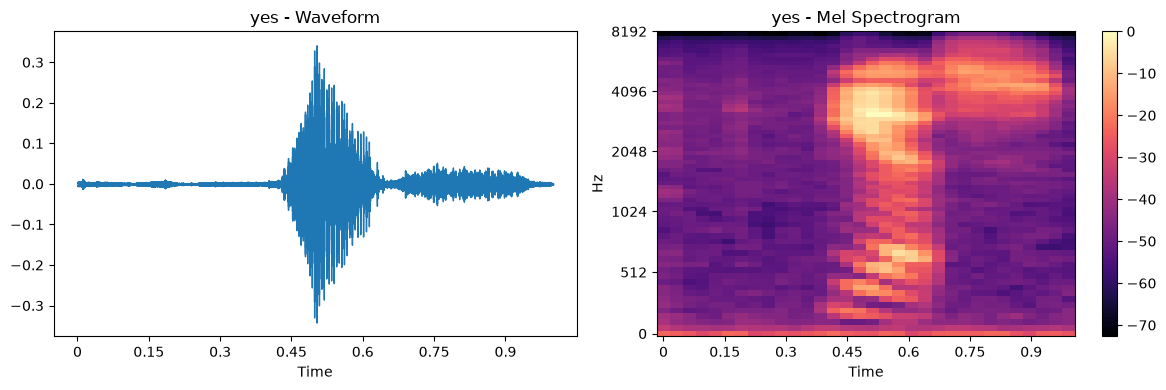


Class: zero
File: D:\onboarding-audio\task4\speech_commands_v0.02\zero\004ae714_nohash_0.wav


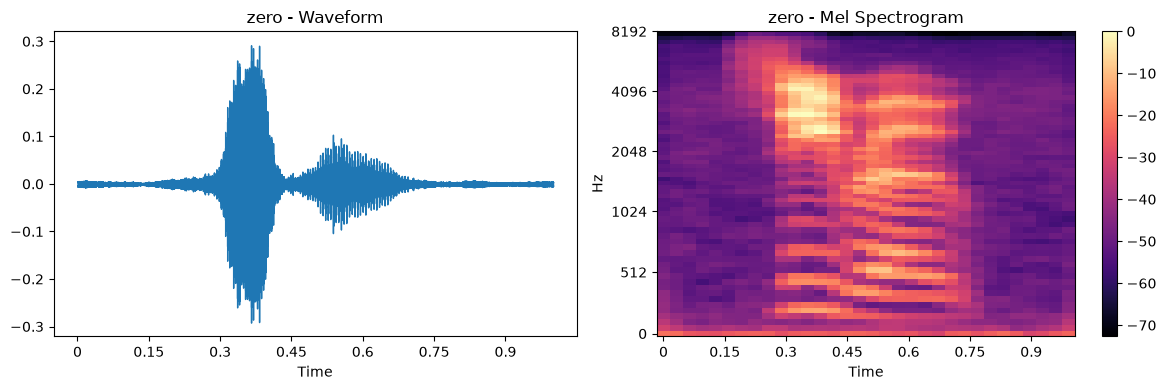

In [10]:
for cls, filepath in sample_files:

    print("\nClass:", cls)
    print("File:", filepath)

    # Play audio
    display(
        ipd.Audio(filepath)
    )


    y, sr = librosa.load(
        filepath,
        sr=None
    )


    plt.figure(figsize=(12,4))


    # Waveform
    plt.subplot(1,2,1)

    librosa.display.waveshow(
        y,
        sr=sr
    )

    plt.title(
        f"{cls} - Waveform"
    )


    # Spectrogram

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=64
    )


    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )


    plt.subplot(1,2,2)

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar()

    plt.title(
        f"{cls} - Mel Spectrogram"
    )


    plt.tight_layout()

    plt.show()

In [11]:
class AudioPreprocessor:

    def __init__(
        self,
        sr=16000,
        n_mels=64,
        n_fft=1024,
        hop_length=512,
        target_duration=1.0
    ):

        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length

        self.target_samples = int(
            sr * target_duration
        )


    def load_and_resample(self, path):

        """
        Load audio file,
        convert to mono,
        resample to target sample rate
        """

        y, sr = librosa.load(
            path,
            sr=None,
            mono=True
        )


        if sr != self.sr:

            y = librosa.resample(
                y,
                orig_sr=sr,
                target_sr=self.sr
            )


        return y



    def pad_or_truncate(self, y):

        """
        Fix audio length
        """

        if len(y) < self.target_samples:

            y = np.pad(
                y,
                (
                    0,
                    self.target_samples - len(y)
                )
            )

        else:

            y = y[:self.target_samples]


        return y



    def extract_mel_spectrogram(self, y):

        """
        Convert waveform to log mel spectrogram
        Output shape:
        (1, n_mels, frames)
        """


        mel = librosa.feature.melspectrogram(
            y=y,
            sr=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )


        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )


        return mel_db[np.newaxis,:,:]



    def process(self, path):

        y = self.load_and_resample(path)

        y = self.pad_or_truncate(y)

        spec = self.extract_mel_spectrogram(y)


        return spec

In [12]:
processor = AudioPreprocessor()


example_file = df.iloc[0]["path"]


spec = processor.process(
    example_file
)


print("Spectrogram shape:")
print(spec.shape)

Spectrogram shape:
(1, 64, 32)


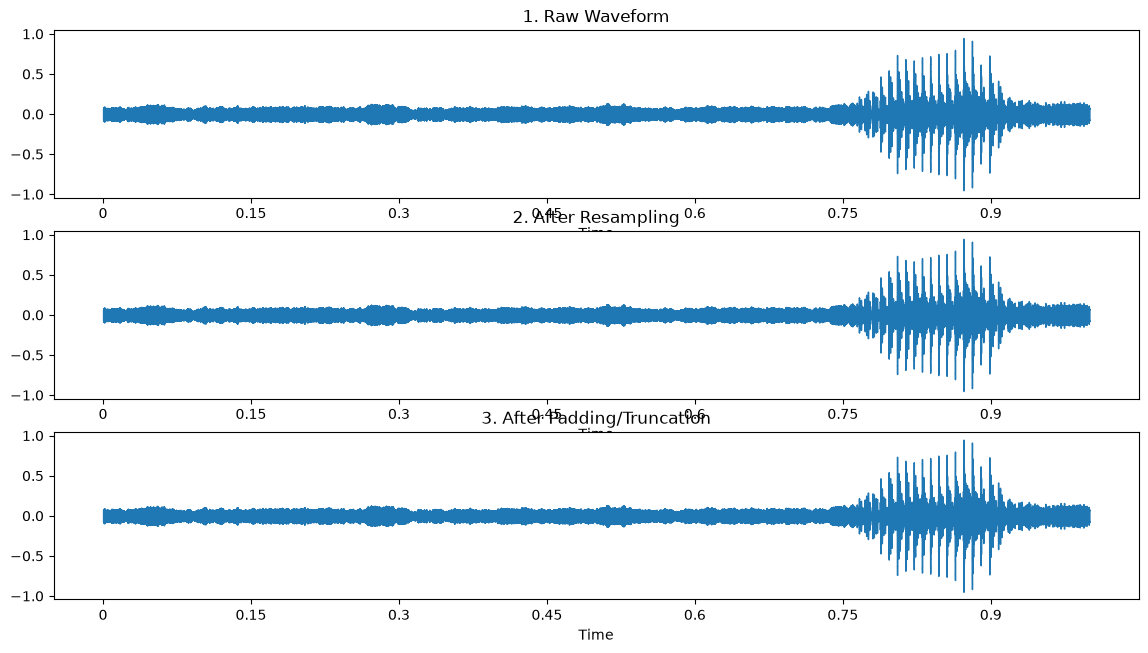

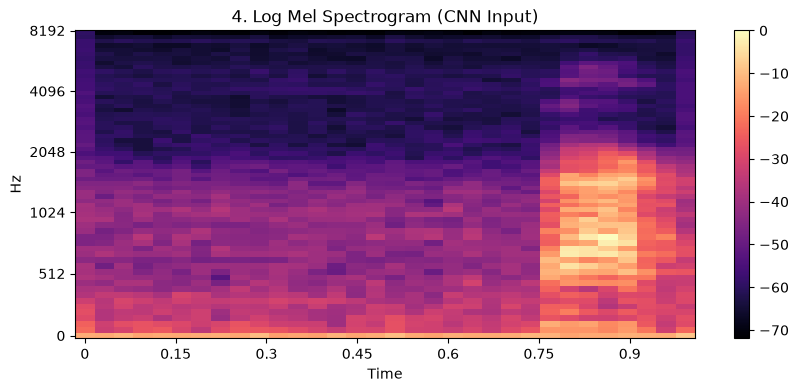

In [13]:
y_raw, sr_raw = librosa.load(
    example_file,
    sr=None
)


y_resampled = processor.load_and_resample(
    example_file
)


y_fixed = processor.pad_or_truncate(
    y_resampled
)


mel_spec = processor.extract_mel_spectrogram(
    y_fixed
)



plt.figure(figsize=(14,10))


# Raw waveform

plt.subplot(4,1,1)

librosa.display.waveshow(
    y_raw,
    sr=sr_raw
)

plt.title(
    "1. Raw Waveform"
)



# Resampled waveform

plt.subplot(4,1,2)

librosa.display.waveshow(
    y_resampled,
    sr=16000
)

plt.title(
    "2. After Resampling"
)



# Fixed length

plt.subplot(4,1,3)

librosa.display.waveshow(
    y_fixed,
    sr=16000
)

plt.title(
    "3. After Padding/Truncation"
)



# Mel spectrogram

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_spec[0],
    sr=16000,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title(
    "4. Log Mel Spectrogram (CNN Input)"
)

plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()

df["label_id"] = encoder.fit_transform(
    df["label"]
)


num_classes = len(
    encoder.classes_
)


print("Number of classes:", num_classes)

df.head()

Number of classes: 35


,path,label,label_id
0,D:\onboarding-audio\task4\speech_commands_v0.0...,backward,0
1,D:\onboarding-audio\task4\speech_commands_v0.0...,backward,0
2,D:\onboarding-audio\task4\speech_commands_v0.0...,backward,0
3,D:\onboarding-audio\task4\speech_commands_v0.0...,backward,0
4,D:\onboarding-audio\task4\speech_commands_v0.0...,backward,0


In [15]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label_id"]
)


train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["label_id"]
)


print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

Train: 76460
Validation: 13494
Test: 15875


In [16]:
class AudioDataset(Dataset):

    def __init__(
        self,
        dataframe,
        preprocessor,
        augment=None
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.preprocessor = preprocessor

        self.augment = augment



    def __len__(self):

        return len(self.dataframe)



    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]


        path = row["path"]

        label = row["label_id"]


        # waveform -> mel spectrogram

        spec = self.preprocessor.process(
            path
        )


        spec = torch.tensor(
            spec,
            dtype=torch.float32
        )


        # Apply augmentation only for training

        if self.augment:

            spec = self.augment(spec)



        label = torch.tensor(
            label,
            dtype=torch.long
        )


        return spec, label

In [17]:
processor = AudioPreprocessor(
    sr=16000,
    n_mels=64,
    target_duration=1.0
)



train_dataset = AudioDataset(
    train_df.head(500),
    processor
)


val_dataset = AudioDataset(
    val_df,
    processor
)


test_dataset = AudioDataset(
    test_df,
    processor
)

In [18]:
BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)


val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [19]:
x, y = next(iter(train_loader))


print(
    "Spectrogram batch shape:",
    x.shape
)


print(
    "Label shape:",
    y.shape
)

Spectrogram batch shape: torch.Size([64, 1, 64, 32])
Label shape: torch.Size([64])


In [20]:
class AudioCNN(nn.Module):

    def __init__(self, num_classes):

        super(AudioCNN, self).__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                1,16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d(
                16,32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d(
                32,64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )


        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d((1,1)),

            nn.Flatten(),

            nn.Dropout(0.3),

            nn.Linear(
                64,
                num_classes
            )
        )



    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print("Using device:", device)


model = AudioCNN(
    num_classes
)


model = model.to(device)

Using device: cpu


In [22]:
x,y = next(iter(train_loader))


x=x.to(device)


output=model(x)


print("Input shape :",x.shape)

print("Output shape:",output.shape)

Input shape : torch.Size([64, 1, 64, 32])
Output shape: torch.Size([64, 35])


In [23]:
sample_x, sample_y = next(iter(train_loader))


sample_x = sample_x.to(device)


output = model(sample_x)


print(
    "Input shape:",
    sample_x.shape
)


print(
    "Output shape:",
    output.shape
)

Input shape: torch.Size([64, 1, 64, 32])
Output shape: torch.Size([64, 35])


# Step 5: Training Without Augmentation (Part A)

In this section, the CNN model is trained without any data augmentation.

The objective is to establish a baseline performance and analyze:
- Training loss
- Training accuracy
- Validation accuracy
- Model generalization capability

The same model architecture and dataset split will later be used with SpecAugment to compare performance.

In [24]:
import time

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# Reduce for faster training
EPOCHS = 8


train_losses = []
train_accuracies = []
val_accuracies = []

In [25]:
def validate(model, loader):

    model.eval()

    correct = 0
    total = 0


    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)


            output = model(x)


            pred = torch.argmax(
                output,
                dim=1
            )


            correct += (
                pred == y
            ).sum().item()


            total += y.size(0)


    return correct / total

In [26]:
def validate(
    model,
    loader
):

    model.eval()

    correct = 0
    total = 0


    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)
            y=y.to(device)


            outputs=model(x)


            predictions=outputs.argmax(
                dim=1
            )


            correct += (
                predictions==y
            ).sum().item()


            total += y.size(0)



    accuracy = correct/total


    return accuracy

CUDA Available: False
